In [2]:
print("Hello")


Hello


# 🚗 Car Price Prediction using Machine Learning

## Epochs Bootcamp 2026 - Assignment 5

### Business Objective

The objective of this project is to develop machine learning regression models capable of accurately predicting the selling price of used cars based on their characteristics. Accurate price prediction helps buyers, sellers, and dealerships make informed pricing decisions.

---

### Target Variable

**selling_price**

---

### Dataset

CarDekho Used Car Dataset

---

### Regression Models Used

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [5]:
df = pd.read_csv("../data/cardekho_dataset.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (15411, 14)


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [6]:
# First 10 Records

df.head(10)


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
5,5,Maruti Wagon R,Maruti,Wagon R,8,35000,Individual,Petrol,Manual,18.90,998,67.10,5,350000
6,6,Hyundai i10,Hyundai,i10,8,40000,Dealer,Petrol,Manual,20.36,1197,78.90,5,315000
7,7,Maruti Wagon R,Maruti,Wagon R,3,17512,Dealer,Petrol,Manual,20.51,998,67.04,5,410000
8,8,Hyundai Venue,Hyundai,Venue,2,20000,Individual,Petrol,Automatic,18.15,998,118.35,5,1050000
9,12,Maruti Swift,Maruti,Swift,4,28321,Dealer,Petrol,Manual,16.60,1197,85.00,5,511000


In [7]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [8]:
# Statistical Summary

df.describe(include='all')

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411,15411,15411,15411.000000,1.541100e+04,15411,15411,15411,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
unique,NaN,121,32,120,NaN,NaN,3,5,2,NaN,NaN,NaN,NaN,NaN
top,NaN,Hyundai i20,Maruti,i20,NaN,NaN,Dealer,Petrol,Manual,NaN,NaN,NaN,NaN,NaN
freq,NaN,906,4992,906,NaN,NaN,9539,7643,12225,NaN,NaN,NaN,NaN,NaN
mean,9811.857699,NaN,NaN,NaN,6.036338,5.561648e+04,NaN,NaN,NaN,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,NaN,NaN,NaN,3.013291,5.161855e+04,NaN,NaN,NaN,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,NaN,NaN,NaN,0.000000,1.000000e+02,NaN,NaN,NaN,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,NaN,NaN,NaN,4.000000,3.000000e+04,NaN,NaN,NaN,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,NaN,NaN,NaN,6.000000,5.000000e+04,NaN,NaN,NaN,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,NaN,NaN,NaN,8.000000,7.000000e+04,NaN,NaN,NaN,22.700000,1582.000000,117.300000,5.000000,8.250000e+05


In [9]:
# Missing Values

df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [10]:
# Duplicate Records

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


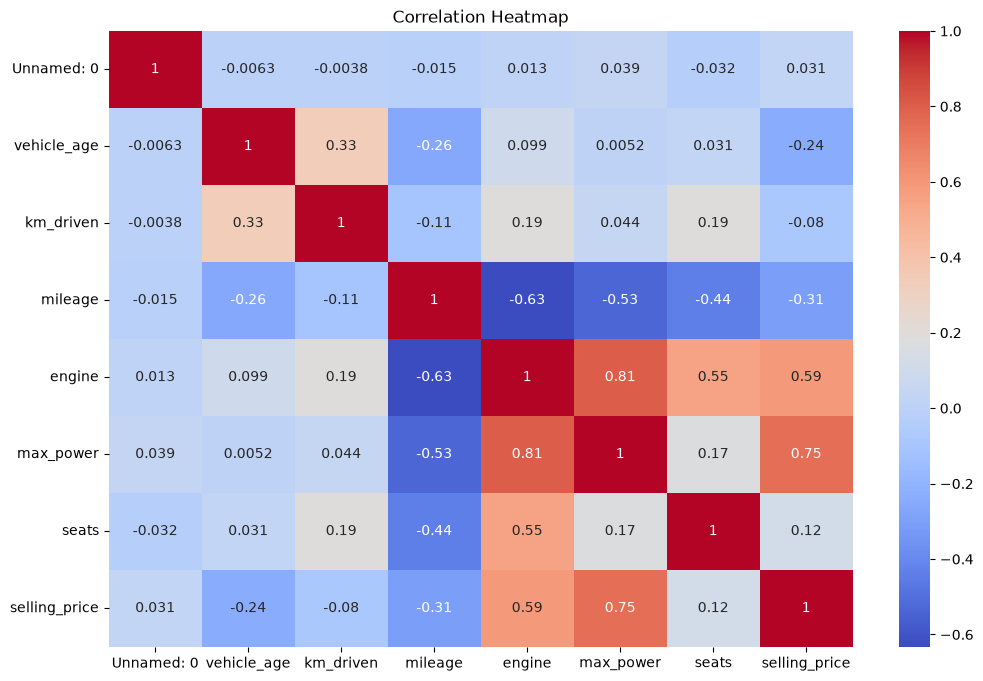

In [11]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

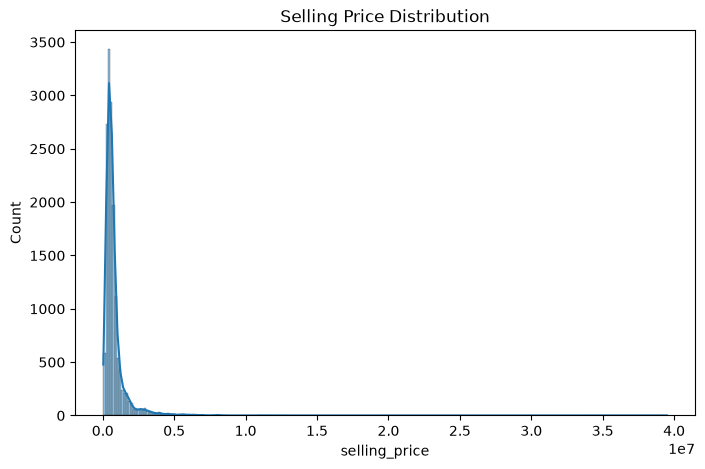

In [12]:
# Selling Price Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["selling_price"], kde=True)

plt.title("Selling Price Distribution")

plt.show()

In [13]:
print(df.columns)

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')


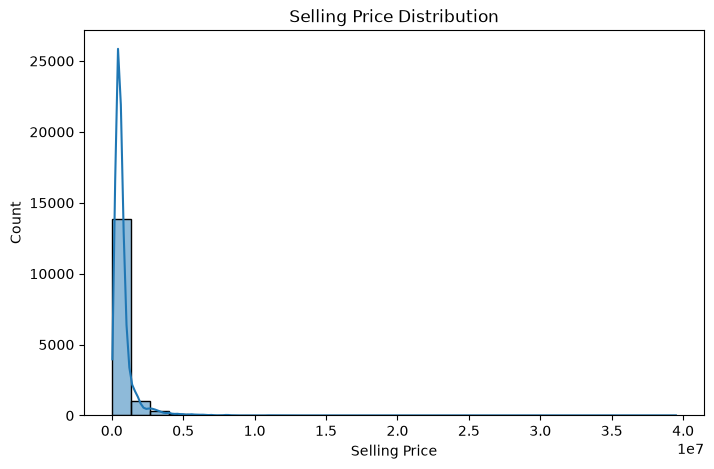

In [14]:
# Selling Price Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["selling_price"], kde=True, bins=30)

plt.title("Selling Price Distribution")
plt.xlabel("Selling Price")
plt.show()

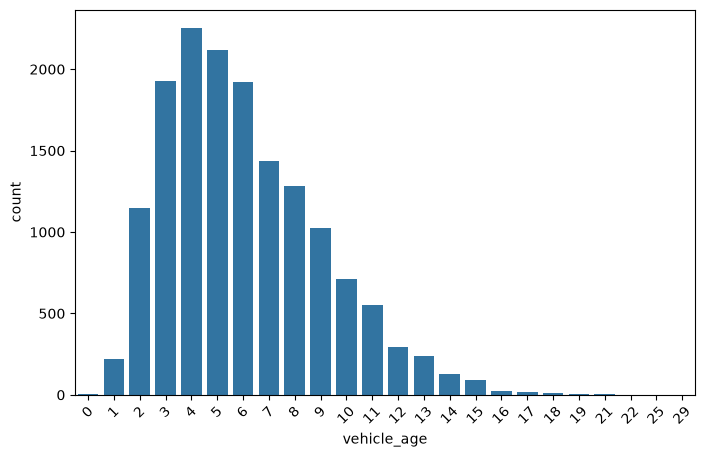

In [15]:
# Vehicle Age Distribution

plt.figure(figsize=(8,5))

sns.countplot(x=df["vehicle_age"])

plt.xticks(rotation=45)

plt.show()

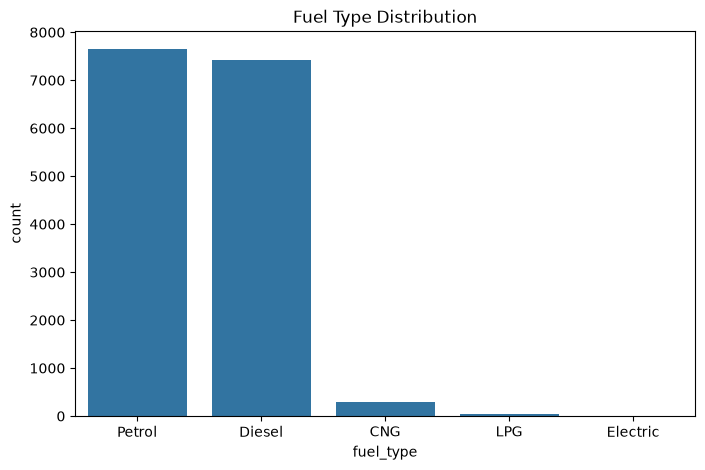

In [16]:
# Fuel Type Distribution

plt.figure(figsize=(8,5))

sns.countplot(x=df["fuel_type"])

plt.title("Fuel Type Distribution")

plt.show()

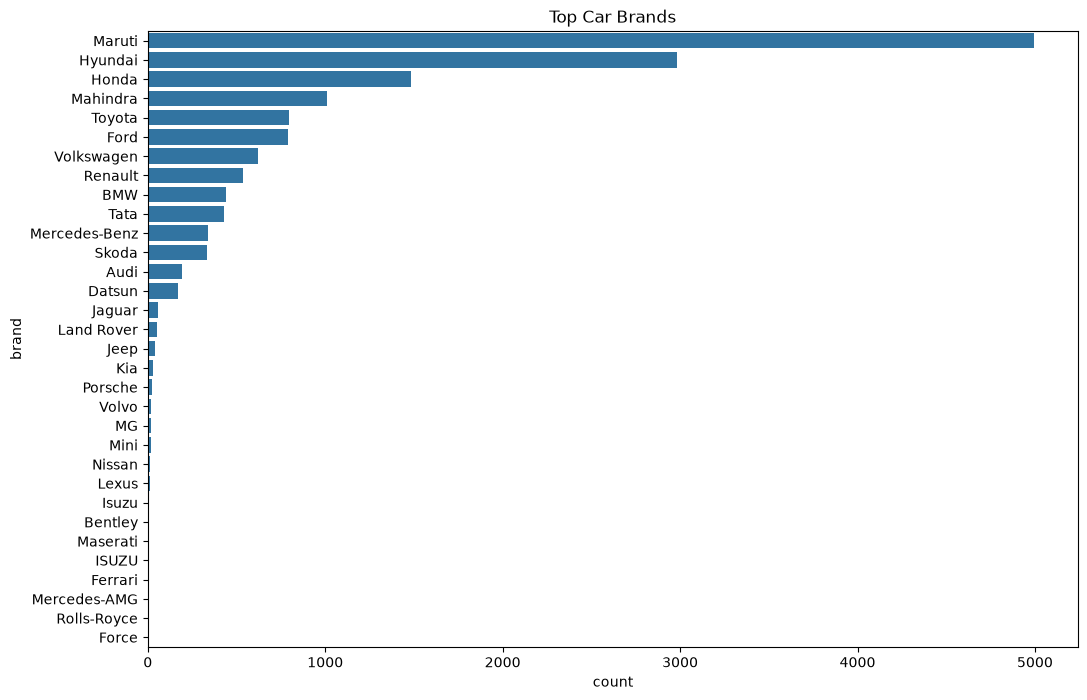

In [17]:
# Top Car Brands

plt.figure(figsize=(12,8))

sns.countplot(
    y=df["brand"],
    order=df["brand"].value_counts().index
)

plt.title("Top Car Brands")

plt.show()

In [18]:
# Remove unnecessary column

df.drop("Unnamed: 0", axis=1, inplace=True)

df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [19]:
# Encode categorical columns

encoder = LabelEncoder()

categorical_columns = [
    "car_name",
    "brand",
    "model",
    "seller_type",
    "fuel_type",
    "transmission_type"
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,65,18,7,9,120000,1,4,1,19.70,796,46.30,5,120000
1,34,8,54,5,20000,1,4,1,18.90,1197,82.00,5,550000
2,40,8,118,11,60000,1,4,1,17.00,1197,80.00,5,215000
3,65,18,7,9,37000,1,4,1,20.92,998,67.10,5,226000
4,20,6,38,6,30000,0,1,1,22.77,1498,98.59,5,570000


In [20]:
# Feature Matrix and Target

X = df.drop("selling_price", axis=1)

y = df["selling_price"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (15411, 12)
Target: (15411,)


In [21]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (12328, 12)
Testing : (3083, 12)


In [22]:
# Linear Regression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression Model Trained")

Linear Regression Model Trained


In [23]:
print("Linear Regression Results")
print("-"*40)

print("MAE :", mean_absolute_error(y_test, lr_pred))
print("MSE :", mean_squared_error(y_test, lr_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score :", r2_score(y_test, lr_pred))

Linear Regression Results
----------------------------------------
MAE : 270049.7834367239
MSE : 250603238588.25293
RMSE : 500602.87512983073
R2 Score : 0.6670971033619301


In [24]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Model Trained")

Decision Tree Model Trained


In [25]:
print("Decision Tree Results")
print("-"*40)

print("MAE :", mean_absolute_error(y_test, dt_pred))
print("MSE :", mean_squared_error(y_test, dt_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R2 Score :", r2_score(y_test, dt_pred))

Decision Tree Results
----------------------------------------
MAE : 123637.43918261434
MSE : 91594752143.22717
RMSE : 302646.2491808335
R2 Score : 0.8783249630886625


In [26]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Model Trained")

Random Forest Model Trained


In [27]:
print("Random Forest Results")
print("-"*40)

print("MAE :", mean_absolute_error(y_test, rf_pred))
print("MSE :", mean_squared_error(y_test, rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score :", r2_score(y_test, rf_pred))

Random Forest Results
----------------------------------------
MAE : 99251.81593813437
MSE : 44474226389.486626
RMSE : 210889.1329336024
R2 Score : 0.9409201617895955


In [28]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "MSE": [
        mean_squared_error(y_test, lr_pred),
        mean_squared_error(y_test, dt_pred),
        mean_squared_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]
})

results.sort_values("R2 Score", ascending=False)

,Model,MAE,MSE,RMSE,R2 Score
2,Random Forest,99251.815938,4.447423e+10,210889.132934,0.940920
1,Decision Tree,123637.439183,9.159475e+10,302646.249181,0.878325
0,Linear Regression,270049.783437,2.506032e+11,500602.875130,0.667097


# Best Model & Justification

Among the three regression models, the Random Forest Regressor achieved the best performance.

- Highest R² Score: 0.9409
- Lowest MAE
- Lowest RMSE

Random Forest performed better because it combines multiple decision trees, reducing overfitting and improving prediction accuracy. Therefore, it is selected as the final model for car price prediction.

# Future Improvements

Possible improvements include:

- Collecting a larger and more diverse dataset.
- Hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
- Applying advanced feature engineering.
- Trying Gradient Boosting models such as XGBoost, LightGBM, and CatBoost.
- Deploying the trained model as a web application using Flask or Streamlit.